<a href="https://colab.research.google.com/github/beatriz-paz/learning-cnn/blob/main/cnn_do_zero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rede Neural Convolucional (CNN)

## 1. Dataset usado: CIFAR-10

* CIFAR-10: Um conjunto de dados bem conhecido que contém 60.000 imagens coloridas de 32x32 pixels em 10 classes diferentes, com 6.000 imagens por classe.

## 2. Pré-processamento de dados

* Normalização: necessário ajustar os valores dos pixels para um intervalo [0, 1] ou [-1, 1].
* Aumento dos dados (quando necessário): aplicar rotação, inversão e recorte na imagem para aumentar a diversidade de possibilidades.


In [3]:
# trecho de código Python para carregar e pré-processar
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Carregar o conjunto de dados CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalizar os dados
x_train = x_train.astype( 'float32' ) / 255.0
x_test = x_test.astype( 'float32' ) / 255.0

# Aumento de dados
datagen = ImageDataGenerator(
   rotation_range= 15 ,
   width_shift_range= 0.1 ,
   height_shift_range= 0.1 ,
   horizontal_flip= True ,
)
datagen.fit(x_train)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## 3. Arquitetura de CNN

### Elementos fundamentais da CNN:

1. Camadas convolucionais;
2. Camadas de Pooling;
3. Camadas totalmente conectadas;
4. Camadas de Dropout.

### Exemplo de arquitetura:

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D( 32 , ( 3 , 3 ), activation= 'relu' , input_shape=( 32 , 32 , 3 )),
    MaxPooling2D(( 2 , 2 )),
    Conv2D( 64 , ( 3 , 3 ), activation= 'relu' ),
    MaxPooling2D(( 2 , 2 )),
    Conv2D( 128 , ( 3 , 3 ), activation= 'relu' ),
    Flatten(),
    Dense( 256 , activation= 'relu' ),
    Dropout( 0.5 ),
    Dense( 10 , activation= 'softmax' )
])

model.compile(optimizer= 'adam' , loss= 'sparse_categorical_crossentropy' , metrics=[ 'accuracy' ])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Treinando o modelo

Com o modelo definido conforme acima, basta treiná-lo.

### Etapas:
[abre aspas]
* Tamanho do lote: o número de amostras processadas antes da atualização do modelo.
* Épocas: O número de vezes que todo o conjunto de dados é transmitido para frente e para trás através da rede.
* Taxa de Aprendizagem: O tamanho do passo do otimizador, que controla o quanto o modelo deve ser alterado em resposta ao erro estimado cada vez que os pesos do modelo são atualizados.

[fechas aspas]

In [9]:
histórico = model.fit(datagen.flow(x_train, y_train, batch_size= 64 ), epochs= 50 , validation_data=(x_test, y_test))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 133ms/step - accuracy: 0.2905 - loss: 1.9126 - val_accuracy: 0.5105 - val_loss: 1.3383
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 129ms/step - accuracy: 0.4660 - loss: 1.4649 - val_accuracy: 0.5473 - val_loss: 1.2414
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 126ms/step - accuracy: 0.5352 - loss: 1.3098 - val_accuracy: 0.6101 - val_loss: 1.1008
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 126ms/step - accuracy: 0.5765 - loss: 1.2084 - val_accuracy: 0.6481 - val_loss: 0.9897
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.5958 - loss: 1.1384 - val_accuracy: 0.6595 - val_loss: 0.9664
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.6182 - loss: 1.0822 - val_accuracy: 0.6726 - val_loss: 0.9309
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 126ms/step - accuracy: 0.6349 - loss: 1.0478 - val_accuracy: 0.6898 - val_loss: 0.8929
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 130ms/step - accuracy: 0.6431 - loss: 1.0199 - 

In [11]:
model.save("meu_modelo.keras")


## 5. Avaliando o modelo

"Após treinar o modelo, é essencial avaliar seu desempenho e ajustar os hiperparâmetros para obter melhores resultados."

### Métricas:

* Precisão;
* Perda.

## Testando o modelo

Após o treinamento do modelo, vamos introduir uma imagem nova para validar se irá conseguir classificar corretamente.

Imagem usada:

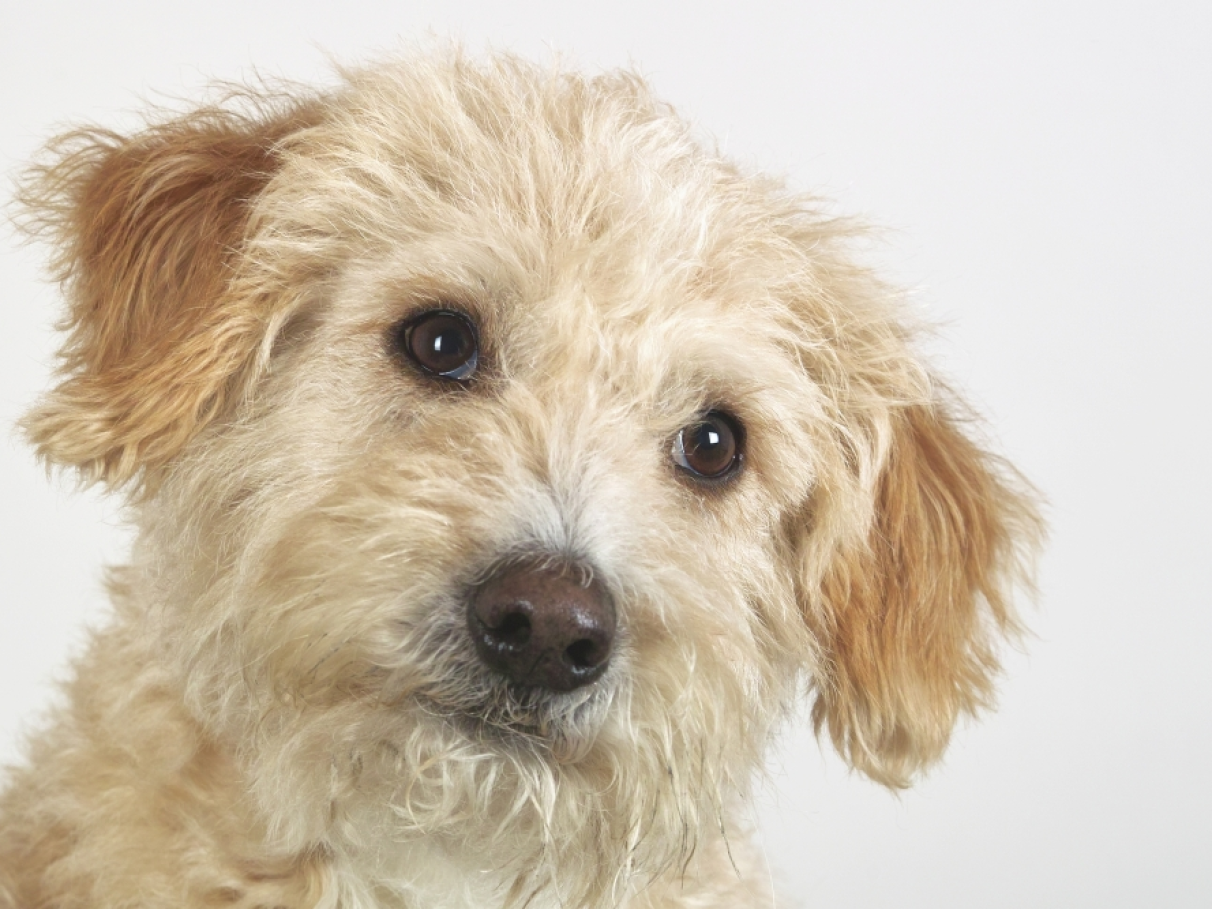

In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image

# Carregar modelo (sem recompilar)
model = tf.keras.models.load_model("meu_modelo.keras", compile=False)

# Carregar imagem no tamanho correto
img = image.load_img("cachorro-vira-lata.jpg", target_size=(32, 32))
img_array = image.img_to_array(img)

# Normalizar
img_array = img_array / 255.0

# Ajustar dimensão
img_array = np.expand_dims(img_array, axis=0)

# Previsão
prediction = model.predict(img_array)

classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

indice = np.argmax(prediction)

print("Classe prevista:", indice)
print("Nome da classe:", classes[indice])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
Classe prevista: 5
Nome da classe: dog


Esta CNN foi implementada seguindo o tutorial: https://medium.com/@sanjay_dutta/designing-your-own-convolutional-neural-network-cnn-model-a-step-by-step-guide-for-beginners-4e8b57836c81

Com adição de mais uns detalhes.